A model for recognizing original and fake products from popular fashion brands

In [25]:
# Install (Colab)

!pip install pyspark pandas pyarrow pillow torchvision

# SPARK

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Fixed_Fashion_Model") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()



In [26]:
# UNZIP

import zipfile
import os

zip_path = "/content/Fake Brand Dataset.zip"
extract_path = "/content/fashion_data"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

In [27]:
# CREATING A DATAFRAME

data = []

for split in os.listdir(extract_path):  # train / test
    split_path = os.path.join(extract_path, split)

    if os.path.isdir(split_path):
        for label in os.listdir(split_path):  # gucci_fake, nike_fake
            class_path = os.path.join(split_path, label)

            if os.path.isdir(class_path):
                for img in os.listdir(class_path):
                    img_path = os.path.join(class_path, img)

                    # we only take images
                    if img.lower().endswith((".jpg", ".jpeg", ".png")):
                        data.append((img_path, label))


df = spark.createDataFrame(data, ["image_path", "label"])

# checking
df.groupBy("label").count().show()

# limit the size (for Colab)
df = df.limit(500)

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)



+--------------+-----+
|         label|count|
+--------------+-----+
| gucci_genuine|  190|
|    gucci_fake|  152|
|   adidas_fake|  140|
|  puma_genuine|  199|
|    lv_genuine|   28|
|     puma_fake|   91|
|       lv_fake|   74|
|  nike_genuine|  260|
|     nike_fake|  253|
|adidas_genuine|  178|
+--------------+-----+



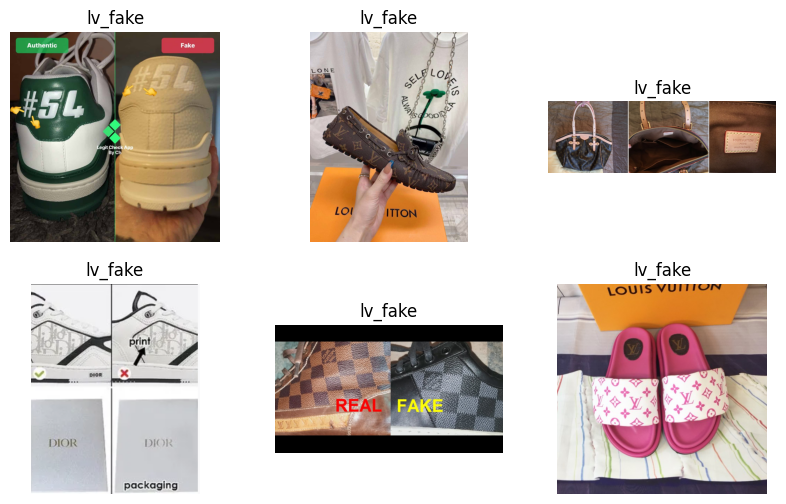

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# we take a random 6 examples
sample = df.limit(50).collect()
samples = random.sample(sample, 6)

plt.figure(figsize=(10, 6))

for i, row in enumerate(samples):
    img = Image.open(row["image_path"])

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.show()

In [29]:
# View all classes

df.select("label").distinct().show()

+-------------+
|        label|
+-------------+
|      lv_fake|
|gucci_genuine|
|   lv_genuine|
|  adidas_fake|
|   gucci_fake|
+-------------+



In [30]:
# How many images are in each class

df.groupBy("label").count().show()

+-------------+-----+
|        label|count|
+-------------+-----+
|      lv_fake|   74|
|gucci_genuine|  190|
|   lv_genuine|   28|
|  adidas_fake|  140|
|   gucci_fake|   68|
+-------------+-----+



In [31]:
df.show(5, False)

+--------------------------------------------------------------------+-------+
|image_path                                                          |label  |
+--------------------------------------------------------------------+-------+
|/content/fashion_data/train/lv_fake/000027.jpg                      |lv_fake|
|/content/fashion_data/train/lv_fake/000013.jpg                      |lv_fake|
|/content/fashion_data/train/lv_fake/Screenshot 2026-03-13 224328.png|lv_fake|
|/content/fashion_data/train/lv_fake/000038.jpg                      |lv_fake|
|/content/fashion_data/train/lv_fake/000062.jpg                      |lv_fake|
+--------------------------------------------------------------------+-------+
only showing top 5 rows


In [32]:
# PYTORCH (THE LIGHTWEIGHT MODEL)

import torch
from torchvision import models, transforms

device = torch.device("cpu")

model = models.mobilenet_v2(weights="IMAGENET1K_V1")
model.classifier = torch.nn.Identity()
model.eval()



MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [33]:
# PREPROCESSING

from PIL import Image

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])



In [34]:
# FEATURE EXTRACTION

import pandas as pd
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import ArrayType, FloatType

@pandas_udf(ArrayType(FloatType()))
def extract_features(paths: pd.Series) -> pd.Series:

    features = []

    for path in paths:
        try:
            img = Image.open(path).convert("RGB")
            img = transform(img).unsqueeze(0)

            with torch.no_grad():
                feat = model(img).squeeze().numpy()

            features.append(feat.tolist())
        except:
            features.append([0.0]*1280)

    return pd.Series(features)



In [35]:
# TRAIN PIPELINE

train_features = train_df.withColumn(
    "features",
    extract_features("image_path")
)

# FIX: convert to Vector
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf

def to_vector(arr):
    return Vectors.dense(arr)

to_vector_udf = udf(to_vector, VectorUDT())

train_features = train_features.withColumn(
    "features",
    to_vector_udf("features")
)


In [36]:
# label encoding
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="label", outputCol="label_index")
indexer_model = indexer.fit(train_features)

train_features = indexer_model.transform(train_features)


# TRAIN MODEL

from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label_index",
    maxIter=10
)

model_lr = lr.fit(train_features)



In [37]:
# TEST PIPELINE

test_features = test_df.withColumn(
    "features",
    extract_features("image_path")
)

test_features = test_features.withColumn(
    "features",
    to_vector_udf("features")
)

test_features = indexer_model.transform(test_features)


In [38]:
# PREDICTIONS

predictions = model_lr.transform(test_features)

predictions.select(
    "image_path",
    "label",
    "prediction"
).show(20, False)

+------------------------------------------------------------------------+-----------+----------+
|image_path                                                              |label      |prediction|
+------------------------------------------------------------------------+-----------+----------+
|/content/fashion_data/train/adidas_fake/000003.jpg                      |adidas_fake|3.0       |
|/content/fashion_data/train/adidas_fake/000007.jpg                      |adidas_fake|1.0       |
|/content/fashion_data/train/adidas_fake/000009.jpg                      |adidas_fake|4.0       |
|/content/fashion_data/train/adidas_fake/000014.jpg                      |adidas_fake|1.0       |
|/content/fashion_data/train/adidas_fake/000020.jpg                      |adidas_fake|3.0       |
|/content/fashion_data/train/adidas_fake/000024.jpg                      |adidas_fake|1.0       |
|/content/fashion_data/train/adidas_fake/000030.jpg                      |adidas_fake|1.0       |
|/content/fashion_da

In [39]:
# METRICS

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

Accuracy: 0.5405405405405406
